In [124]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import clip
import math
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image

def attention_layer(q, k, v, num_heads=1, attn_mask=None):
    """Compute scaled dot product attention"""
    tgt_len, bsz, embed_dim = q.shape
    head_dim = embed_dim // num_heads
    scaling = float(head_dim) ** -0.5
    q = q * scaling
    
    q = q.contiguous().view(tgt_len, bsz * num_heads, head_dim).transpose(0, 1)
    k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    v = v.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    
    attn_output_weights = torch.bmm(q, k.transpose(1, 2))
    if attn_mask is not None:
        attn_output_weights += attn_mask
        
    attn_output_weights = F.softmax(attn_output_weights, dim=-1)
    attn_output = torch.bmm(attn_output_weights, v)
    
    attn_output = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, embed_dim)
    attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, -1)
    attn_output_weights = attn_output_weights.sum(dim=1) / num_heads
    
    return attn_output, attn_output_weights

def clip_encode_text_dense(model, text, n=8):
    """Dense text encoding with attention outputs"""
    x = model.token_embedding(text).type(model.dtype)
    attn_mask = model.build_attention_mask().to(dtype=x.dtype, device=x.device)
    x = x + model.positional_embedding.type(model.dtype)
    x = x.permute(1, 0, 2)  # NLD -> LND
    
    x = torch.nn.Sequential(*model.transformer.resblocks[:-n])(x)
    
    attns = []
    atten_outs = []
    vs = []
    qs = []
    ks = []
    
    for TR in model.transformer.resblocks[-n:]:
        x_in = x
        x = TR.ln_1(x_in)
        linear = torch._C._nn.linear    
        q, k, v = linear(x, TR.attn.in_proj_weight, TR.attn.in_proj_bias).chunk(3, dim=-1)
        attn_output, attn = attention_layer(q, k, v, 1, attn_mask=attn_mask)
        
        attns.append(attn)
        atten_outs.append(attn_output)
        vs.append(v)
        qs.append(q)
        ks.append(k)
        
        x_after_attn = linear(attn_output, TR.attn.out_proj.weight, TR.attn.out_proj.bias)       
        x = x_after_attn + x_in
        x = x + TR.mlp(TR.ln_2(x))
    x_features = x        
    x = x.permute(1, 0, 2)  # LND -> NLD
    x = model.ln_final(x).type(model.dtype)
    x = x[torch.arange(x.shape[0]), text.argmax(dim=-1)] @ model.text_projection
    print("dense text embeddings", x.shape)
    return x, (qs, ks, vs), attns, atten_outs, x_features

def clip_encode_image_dense(model, image, n=1):
    """Dense image encoding with attention outputs"""
    x = model.visual.conv1(image)
    x = x.reshape(x.shape[0], x.shape[1], -1)
    x = x.permute(0, 2, 1)
    x = torch.cat([model.visual.class_embedding.to(x.dtype) + 
                  torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device), x], dim=1)
    x = x + model.visual.positional_embedding.to(x.dtype)
    x = model.visual.ln_pre(x)
    
    x = x.permute(1, 0, 2)
    x = torch.nn.Sequential(*model.visual.transformer.resblocks[:-n])(x)
    
    attns = []
    atten_outs = []
    vs = []
    qs = []
    ks = []
    
    for TR in model.visual.transformer.resblocks[-n:]:
        x_in = x
        x = TR.ln_1(x_in)
        linear = torch._C._nn.linear
        q, k, v = linear(x, TR.attn.in_proj_weight, TR.attn.in_proj_bias).chunk(3, dim=-1)
        attn_output, attn = attention_layer(q, k, v, 1)
        
        attns.append(attn)
        atten_outs.append(attn_output)
        vs.append(v)
        qs.append(q)
        ks.append(k)
        
        x_after_attn = linear(attn_output, TR.attn.out_proj.weight, TR.attn.out_proj.bias)
        x = x_after_attn + x_in
        x = x + TR.mlp(TR.ln_2(x))
    
    x = x.permute(1, 0, 2)
    x = model.visual.ln_post(x[:, 0, :])
    x = x @ model.visual.proj
    print("dense image embeddings", x.shape)
    return x, (qs, ks, vs), attns, atten_outs, x_in
"""
def sim_qk(q, k):
    q_cls = F.normalize(q[:1,0,:], dim=-1)
    k_patch = F.normalize(k[1:,0,:], dim=-1)
    cosine_qk = (q_cls * k_patch).sum(-1)
    # Min-max normalization, but with epsilon for stability
    cosine_qk_max = cosine_qk.max(dim=-1, keepdim=True)[0]
    cosine_qk_min = cosine_qk.min(dim=-1, keepdim=True)[0]
    cosine_qk = (cosine_qk-cosine_qk_min) / (cosine_qk_max-cosine_qk_min + 1e-8)
    return cosine_qk
    """
def sim_qk(q, k, position=0):
    """Compute similarity between query and key"""
    q_cls = F.normalize(q[:1,0,:], dim=-1)
    # Exclude CLS token from key vectors like original
    k_patch = F.normalize(k[1:,0,:], dim=-1)
    
    cosine_qk = (q_cls * k_patch).sum(-1)
    # Keep epsilon for stability like original
    cosine_qk_max = cosine_qk.max(dim=-1, keepdim=True)[0]
    cosine_qk_min = cosine_qk.min(dim=-1, keepdim=True)[0]
    cosine_qk = (cosine_qk-cosine_qk_min) / (cosine_qk_max-cosine_qk_min + 1e-8)
    return cosine_qk

def grad_eclip_enhanced(c, qs, ks, vs, attn_outputs, map_size=None, position=0):
    """Enhanced gradient-based attention computation"""
    tmp_maps = []
    enhanced_features = []
    
    for q, k, v, attn_output in zip(qs, ks, vs, attn_outputs):
        grad = torch.autograd.grad(
            c,
            attn_output,
            retain_graph=True)[0]
        
        # Use CLS token gradient like original
        grad_cls = grad[:1,0,:]
        # Exclude CLS token from value vectors like original
        v_patch = v[1:,0,:]
        
        # Use modified sim_qk that matches original
        cosine_qk = sim_qk(q, k).reshape(-1)
        
        # Add sqrt dampening like original
        attn_map = (grad_cls * v_patch * torch.sqrt(cosine_qk[:,None])).sum(-1)
        tmp_maps.append(attn_map)
        
        # Keep enhanced features calculation for additional functionality
        enhanced_feat = grad_cls * v_patch * torch.sqrt(cosine_qk[:,None])
        enhanced_features.append(enhanced_feat)
    
    emap = F.relu_(torch.stack(tmp_maps, dim=0)).sum(0)
    enhanced_feats = torch.stack(enhanced_features).sum(0)
    print(f"enhanced emap: {emap}")
    return emap, enhanced_feats


def grad_eclip_enhanced_02(c, qs, ks, vs, attn_outputs, position=0):
    tmp_maps = []
    enhanced_features = []
    
    for q, k, v, attn_output in zip(qs, ks, vs, attn_outputs):
        grad = torch.autograd.grad(
            c,
            attn_output,
            retain_graph=True)[0]
        
        grad_cls = grad[position,0,:]
        v_patch = v[:,0,:]
        cosine_qk = sim_qk(q, k, position).reshape(-1)  # Now with correct position parameter
        
        # Use raw attention scores without sqrt dampening
        attn_map = (grad_cls * v_patch * cosine_qk[:,None]).sum(-1)
        tmp_maps.append(attn_map)
        
        # Enhanced features with less dampening
        enhanced_feat = grad_cls * v_patch * cosine_qk[:,None]
        enhanced_features.append(enhanced_feat)
    
    emap = F.relu_(torch.stack(tmp_maps, dim=0)).sum(0)
    enhanced_feats = torch.stack(enhanced_features).sum(0)
    
    return emap, enhanced_feats
    




def grad_eclip_enhanced_old1(c, qs, ks, vs, attn_outputs, features, position=0, temperature=0.1):
    enhanced_features = []
    tmp_maps = []
    
    for q, k, v, attn_output in zip(qs, ks, vs, attn_outputs):
        # Get gradients w.r.t attention output
        grad = torch.autograd.grad(c, attn_output, retain_graph=True)[0]
        
        # Get cls gradient and patch values (following original grad_eclip)
        grad_cls = grad[position, 0, :]  # [512]
        v_patch = v[1:, 0, :]  # Remove cls token [76, 512]
        
        # Get attention scores
        cosine_qk = sim_qk(q, k, position)  # [77]
        cosine_qk = cosine_qk[1:]  # Remove cls token score [76]
        
        # Compute feature map (following original implementation)
        feature_map = (grad_cls * v_patch * cosine_qk[:, None]).sum(-1)
        tmp_maps.append(feature_map)
        
        # Compute enhanced features using same components
        enhanced_feat = v_patch * cosine_qk[:, None] * grad_cls
        enhanced_features.append(enhanced_feat)
    
    # Combine across layers
    feature_map = F.relu_(torch.stack(tmp_maps, dim=0)).sum(0)
    enhanced_feats = torch.stack(enhanced_features).mean(0)
    
    print(f"Feature map shape: {feature_map.shape}")
    print(f"Enhanced features shape: {enhanced_feats.shape}")
    print(f"Feature map shape: {feature_map}")
    print(f"Enhanced features shape: {enhanced_feats}")
    
    return feature_map, enhanced_feats



def grad_eclip_enhanced_old(c, qs, ks, vs, attn_outputs, features, position=0, temperature=0.1):
    """Compute gradient-based attention and enhanced features with temperature scaling"""
    enhanced_features = []
    attention_maps = []
    
    for q, k, v, attn_output in zip(qs, ks, vs, attn_outputs):
        grad = torch.autograd.grad(c, attn_output, retain_graph=True)[0]
        grad_cls = F.normalize(grad[position,0,:], dim=-1)
        
        # Raw cosine similarity
        raw_cosine_qk = sim_qk(q, k, position)
        v_features = F.normalize(v[:,0,:], dim=-1)
        
        # Calculate attention map using raw similarity
        attn_map = (grad_cls * v_features * raw_cosine_qk[:,None]).sum(-1)
        attention_maps.append(attn_map)

        # Weighted combination with temperature scaling
        attn_weights = F.softmax(raw_cosine_qk / temperature, dim=0)  # Add temperature scaling
        print(f"Attention weight range: {attn_weights.min():.3f} to {attn_weights.max():.3f}")
        #print("v_features: ", v_features)
        enhanced_feat = v_features * attn_weights[:,None] * grad_cls
        enhanced_features.append(enhanced_feat)
    
    attention_map = F.relu_(torch.stack(attention_maps, dim=0)).sum(0)
    enhanced_feat = torch.stack(enhanced_features, dim=0).sum(0)
    #print("enhanced_feat: ", enhanced_feat)
    print("enhanced enhanced_feat shape", enhanced_feat.shape)
    print("enhanced attention_map shape", attention_map.shape)
    print("enhanced enhanced_feat shape", enhanced_feat)
    print("enhanced attention_map shape", attention_map)
    return attention_map, enhanced_feat

class CLIPGradientAnalyzer:
    def __init__(self, model_name="ViT-B/16", device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model, self.preprocess = clip.load(model_name, device=self.device)
        # Get the tokenizer from clip
        try:
            import open_clip
            self.tokenizer = open_clip.get_tokenizer(model_name)
        except:
            # If open_clip is not available, use a simpler tokenization
            self.tokenizer = None

    def get_tokens(self, text):
        """Get individual tokens from text"""
        if self.tokenizer:
            # Use open_clip tokenizer if available
            tokens = self.tokenizer(text)
            return tokens[1:-1]  # Remove start and end tokens
        else:
            # Simple tokenization fallback
            return text.split()

    def analyze(self, image_path, text, return_tensors=False):
        # Process image
        image = Image.open(image_path).convert('RGB')
        image_input = self.preprocess(image).unsqueeze(0).to(self.device)
        image_input = image_input.half()
        
        # Process text
        text_tokens = clip.tokenize([text]).to(self.device)
        # Get individual tokens for visualization
        tokens = self.get_tokens(text)
        
        # Get embeddings and attention outputs
        with torch.set_grad_enabled(True):
            # Image pathway
            img_embedding, (img_qs, img_ks, img_vs), img_attns, img_outputs, img_features = \
                clip_encode_image_dense(self.model, image_input, n=1)
            img_embedding = F.normalize(img_embedding, dim=-1)
            
            # Text pathway
            text_embedding, (text_qs, text_ks, text_vs), text_attns, text_outputs, text_features = \
                clip_encode_text_dense(self.model, text_tokens, n=8)
            text_embedding = F.normalize(text_embedding, dim=-1)

            
            # Compute similarity score
            cosine_sim = (img_embedding @ text_embedding.T)[0]
            
            # Get enhanced features for both modalities
            
            eos_position = text_tokens.argmax(dim=-1)
            # For text
            text_attn_map, text_enhanced = grad_eclip_enhanced(
                cosine_sim, text_qs, text_ks, text_vs, text_outputs)
            
            # For image
            image_attn_map, image_enhanced = grad_eclip_enhanced(
                cosine_sim, img_qs, img_ks, img_vs, img_outputs)
            
       
            
            #print(f"get analyzer enhanced image: {image_enhanced}")
            #print(f"get analyzer enhanced text: {text_enhanced}")
            #print(f"get analyzer enhanced image shape: {image_attn_map.shape}")
            #print(f"get analyzer enhanced text shape: {text_attn_map.shape}")
            #print(f"get analyzer enhanced image: {image_attn_map}")
            #print(f"get analyzer enhanced text: {text_attn_map}")
        
        if return_tensors:
            return {
                'image_attn_map': image_attn_map,
                'image_enhanced': image_enhanced,
                'text_attn_map': text_attn_map,
                'text_enhanced': text_enhanced,
                'original_image': image,
                'cosine_similarity': cosine_sim,
                'tokens': tokens,  # Add this
                'text_tokens': text_tokens  # Add this
            }
        
        # Convert to numpy arrays
        return {
            'image_attn_map': image_attn_map.cpu().numpy(),
            'image_enhanced': image_enhanced.cpu().numpy(),
            'text_attn_map': text_attn_map.cpu().numpy(),
            'text_enhanced': text_enhanced.cpu().numpy(),
            'original_image': np.array(image),
            'cosine_similarity': cosine_sim.item(),
            'tokens': tokens.item(),
            'text_tokens': text_tokens.item()
        }



In [125]:
#Information Bottleneck

In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import cv2
from torchvision.transforms import Compose, ToTensor, Normalize, Resize, InterpolationMode
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.text import Text
from typing import List, Union
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.text import Text
import cv2
from typing import List, Union
import torch

class Estimator:
    """Calculates empirical mean and variance of intermediate feature maps."""
    def __init__(self, layer):
        self.layer = layer
        self.M = None  # running mean
        self.S = None  # running std
        self.N = None  # running num_seen
        self.num_seen = 0
        self.eps = 1e-5

    def feed(self, z: np.ndarray):
        if self.N is None:
            self.M = np.zeros_like(z, dtype=float)
            self.S = np.zeros_like(z, dtype=float)
            self.N = np.zeros_like(z, dtype=float)

        self.num_seen += 1
        diff = (z - self.M)
        self.N += 1
        self.M += diff / self.num_seen
        self.S += diff * (z - self.M)

    def mean(self):
        return self.M.squeeze()

    def std(self, stabilize=True):
        if stabilize:
            return np.sqrt(np.maximum(self.S, self.eps) / np.maximum(self.N, 1.0))
        return np.sqrt(self.S / self.N)

class CLIPInformationBottleneck(nn.Module):
    def __init__(self, feature_dim, beta=0.001, device=None):  # Much smaller beta
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.feature_dim = feature_dim
        self.beta = beta
        self.initial_value = 1.0  # Lower initial value
        
        self.alpha = nn.Parameter(torch.full((1, feature_dim),
                                fill_value=self.initial_value, 
                                device=self.device,
                                dtype=torch.float32))
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.to(dtype=torch.float32, device=self.device)
        
        # Softer gating
        lamb = (self.sigmoid(self.alpha) + 0.5) / 2  # Biased towards keeping features
        lamb = lamb.expand(x.shape[0], -1)
        
        # Less aggressive masking
        masked_features = x * lamb
        masked_var = torch.clamp((1 - lamb) ** 2, min=1e-6, max=0.5)
        
        self.buffer_capacity = self._calc_capacity(masked_features, masked_var)
        return self._sample_t(masked_features, masked_var)
    """
    def forward(self, x):
        x = x.to(dtype=torch.float32, device=self.device)
        
        # Handle sequence length dimension
        batch_size = x.shape[0]
        seq_len = x.shape[1] if x.dim() > 2 else 1
        
        # Reshape input if needed
        if x.dim() > 2:
            x = x.view(batch_size * seq_len, -1)
        
        # Expand alpha to match input dimensions
        lamb = self.sigmoid(self.alpha)
        lamb = lamb.expand(batch_size * seq_len, -1)
        
        # Calculate masked features and variance
        masked_features = x * lamb
        masked_var = torch.clamp((1 - lamb) ** 2, min=1e-8)
        
        # Calculate capacity and sample
        self.buffer_capacity = self._calc_capacity(masked_features, masked_var)
        z = self._sample_t(masked_features, masked_var)
        
        # Reshape back if needed
        if x.dim() > 2:
            z = z.view(batch_size, seq_len, -1)
            
        return z
        """
    
    def _sample_t(self, mu, noise_var):
        noise_std = torch.sqrt(torch.clamp(noise_var, min=1e-8))
        eps = torch.randn_like(mu, device=self.device)
        return mu + noise_std * eps
    
    def _calc_capacity(self, mu, var):
        """Calculate KL divergence for each position"""
        log_var = torch.log(var + 1e-8)
        # Calculate KL divergence components
        kl_components = -0.5 * (1 + log_var - mu.pow(2) - var)
        # Sum across feature dimension to get per-position importance
        kl_div = torch.sum(kl_components, dim=-1)
        return kl_div



In [127]:
class CLIPIBAInterpreter:
    def __init__(self, beta=0.5, steps=100, lr=0.5, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.beta = beta
        self.steps = steps
        self.lr = lr


    def interpret(self, features):
        feature_dim = features.shape[-1]
        bottleneck = CLIPInformationBottleneck(
            feature_dim=feature_dim,
            beta=self.beta,
            device=self.device
        ).to(self.device)
        
        features = features.to(dtype=torch.float32, device=self.device)
        
        optimizer = torch.optim.Adam(bottleneck.parameters(), lr=self.lr)
        losses = []
        
        for _ in tqdm(range(self.steps), desc="Training IB"):
            optimizer.zero_grad()
            
            # Forward pass
            processed_features = bottleneck(features)
            
            # Compute losses
            compression_loss = bottleneck.buffer_capacity.mean()
            
            # Reshape for cosine similarity if needed
            proc_feat = processed_features.view(-1, processed_features.shape[-1])
            orig_feat = features.view(-1, features.shape[-1])
            
            reconstruction_loss = 1 - F.cosine_similarity(
                proc_feat,
                orig_feat,
                dim=-1
            ).mean()
            
            # Total loss
            total_loss = self.beta * compression_loss + reconstruction_loss
            
            # Backward pass with retain_graph=True
            if not torch.isnan(total_loss):
                total_loss.backward(retain_graph=True)
                torch.nn.utils.clip_grad_norm_(bottleneck.parameters(), max_norm=1.0)
                optimizer.step()
                losses.append(total_loss.item())
        
        # Get importance scores per position
        importance = bottleneck.buffer_capacity.detach()  # Keep all dimensions
        importance = torch.nan_to_num(importance, 0.0)
        
        # Average over batch dimension if present
        if importance.dim() > 1:
            importance = importance.mean(dim=0)
            
        return importance.cpu().numpy(), losses

        
def get_modality_estimator(features, layer, var=1.0):
    """Create estimator for text or vision modality"""
    estimator = Estimator(layer)
    estimator.M = torch.zeros_like(features, device=features.device)
    estimator.S = var * torch.ones_like(features, device=features.device)
    estimator.N = torch.ones_like(features, device=features.device)
    estimator.num_seen = 1
    return estimator

In [128]:

#-------------------------------------------------------------------------------------------

class TextWithBGColor(Text):
    """Custom Text class that supports background colors"""
    def __init__(self, x, y, text, bgcolor, *args, **kwargs):
        super().__init__(x, y, text, *args, **kwargs)
        self.bgcolor = bgcolor
        
    def draw(self, renderer, *args, **kwargs):
        bbox = dict(facecolor=self.bgcolor, 
                   edgecolor=self.bgcolor,
                   boxstyle='round,pad=0.01', 
                   alpha=self.bgcolor[3])
        self.set_bbox(bbox)
        super().draw(renderer, *args, **kwargs)

def normalize_map(attention_map: Union[np.ndarray, torch.Tensor]) -> np.ndarray:
    """Normalize attention map to range [0,1]"""
    if torch.is_tensor(attention_map):
        attention_map = attention_map.detach().cpu().numpy()
    
    attention_map = np.nan_to_num(attention_map, 0)
    min_val = attention_map.min()
    max_val = attention_map.max()
    if max_val > min_val:
        attention_map = (attention_map - min_val) / (max_val - min_val)
    else:
        attention_map = np.zeros_like(attention_map)
    
    return attention_map

def create_heatmap(image: np.ndarray, attention_map: np.ndarray) -> np.ndarray:
    """Create heatmap overlay on image using CAM style visualization"""
    image = np.asarray(image)
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    h, w = image.shape[:2]
    attention_map = cv2.resize(attention_map.astype(np.float32), (w, h))
    
    # Convert to RGB heatmap
    heatmap = cv2.applyColorMap((attention_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay with different blending
    return cv2.addWeighted(image, 0.7, heatmap, 0.3, 0)

def generate_shades_with_alpha(scores: List[float], min_alpha: float = 0, max_alpha: float = 0.8) -> List[tuple]:
    """Generate color shades based on importance scores"""
    normalized_scores = [(score - min(scores)) / (max(scores) - min(scores)) for score in scores]
    colors = []
    for score in normalized_scores:
        alpha = min_alpha + score * (max_alpha - min_alpha)
        color = (0.2, 0.4, 1, alpha)  # Blue with varying alpha
        colors.append(color)
    return colors

def plot_text_with_colors_1(ax, tokens: List[str], rgba_colors: List[tuple], 
                         max_width: int = 100, max_height: int = 4, 
                         fontsize: int = 12):
    """Plot text tokens with background colors in a wrapped format"""
    x, y = 0, max_height
    space_width = fontsize * 0.2
    
    for i, (token, color) in enumerate(zip(tokens, rgba_colors)):
        print(f"input to TextWithBGColor: {x}")
        text = TextWithBGColor(x, y*0.7, token, color, fontsize=fontsize)
        ax.add_artist(text)
        
        token_width = fontsize * 0.4 * len(token)
        if i + 1 < len(tokens):
            next_token_width = fontsize * 0.4 * len(tokens[i + 1]) + space_width
            if x + token_width + next_token_width >= max_width:
                x = 0
                y -= 1
            else:
                x += token_width + space_width
        else:
            x += token_width

def plot_text_with_colors(ax, tokens: List[str], rgba_colors: List[tuple], 
                         max_width: int = 100, max_height: int = 4, 
                         fontsize: int = 12):
    x, y = 0, max_height
    space_width = fontsize * 0.3  # Increased spacing
    token_widths = [fontsize * 0.5 * len(token) for token in tokens]  # Pre-calculate widths
    
    current_line_tokens = []
    current_line_width = 0
    
    # First pass: determine line breaks
    lines = []
    current_line = []
    current_width = 0
    
    for i, (token, width) in enumerate(zip(tokens, token_widths)):
        if current_width + width + space_width > max_width:
            lines.append(current_line)
            current_line = [i]
            current_width = width + space_width
        else:
            current_line.append(i)
            current_width += width + space_width
    if current_line:
        lines.append(current_line)
    
    # Second pass: render tokens with proper spacing
    for line_idx, line in enumerate(lines):
        x = 0  # Start at left margin
        y_pos = max_height - (line_idx * 1.2)  # Add vertical spacing between lines
        
        for token_idx in line:
            token = tokens[token_idx]
            color = rgba_colors[token_idx]
            
            text = TextWithBGColor(x, y_pos*0.7, token, color, fontsize=fontsize)
            ax.add_artist(text)
            
            x += token_widths[token_idx] + space_width
            
def visualize_attention(image: np.ndarray, 
                       attention_map: Union[np.ndarray, torch.Tensor],
                       tokens: List[str],
                       text_importance: Union[np.ndarray, torch.Tensor],
                       title: str = "Attention Visualization",
                       max_width: int = 100,
                       max_height: int = 4):
    """Display image heatmap and text importance side by side"""
    # Normalize maps
    attention_map = normalize_map(attention_map)
    text_importance = normalize_map(text_importance)
    
    # Create the heatmap
    heatmap = create_heatmap(image, attention_map)
    
    # Create figure
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot image heatmap
    axs[0].imshow(heatmap)
    axs[0].set_title('Image Attention')
    axs[0].axis('off')
    
    # Generate colors for text visualization
    rgba_colors = generate_shades_with_alpha(text_importance)
    
    # Plot colored text
    plot_text_with_colors(axs[1], tokens, rgba_colors, 
                         max_width=max_width, 
                         max_height=max_height, 
                         fontsize=14)
    
    axs[1].set_xlim(0, max_width)
    axs[1].set_ylim(-max_height, max_height)
    axs[1].set_title('Text Token Importance')
    axs[1].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
#-------------------------------------------------------------------------------------------

def analyze_features_with_ib(image_enhanced, text_enhanced, original_image, tokens, beta=0.1, steps=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Create interpreters
    image_interpreter = CLIPIBAInterpreter(beta=beta, steps=steps, device=device)
    text_interpreter = CLIPIBAInterpreter(beta=beta, steps=steps, device=device)
    
    # Convert inputs to tensors if needed
    image_enhanced = torch.as_tensor(image_enhanced, device=device)
    text_enhanced = torch.as_tensor(text_enhanced, device=device)
    
    # Get importance scores
    image_importance, image_losses = image_interpreter.interpret(image_enhanced)
    text_importance, text_losses = text_interpreter.interpret(text_enhanced)
    
    # Process image importance
    patch_size = int(np.sqrt(image_enhanced.shape[0] - 1))
    patch_importance = image_importance[1:patch_size*patch_size + 1]
    image_map = patch_importance.reshape(patch_size, patch_size)
    
    # Process text importance
    text_map = text_importance[:len(tokens)]
    
    # Visualize results
    visualize_attention(
        image=original_image,
        attention_map=image_map,
        tokens=tokens,
        text_importance=text_map,
        title="CLIP Attention Analysis"
    )
    
    return image_map, text_map, (image_losses, text_losses), original_image


dense image embeddings torch.Size([1, 512])
dense text embeddings torch.Size([1, 512])
enhanced emap: tensor([0.0000e+00, 1.4341e-04, 5.7578e-05, 2.8062e-04, 2.7227e-04, 9.9957e-05,
        7.4983e-05, 9.2566e-05, 5.2881e-04, 3.9101e-05, 8.5068e-04, 3.3760e-04,
        1.3614e-04, 1.4806e-04, 1.4782e-04, 1.5211e-04, 1.6475e-04, 1.6534e-04,
        1.6713e-04, 1.6928e-04, 1.6844e-04, 1.5974e-04, 1.5283e-04, 1.4901e-04,
        1.4210e-04, 1.3602e-04, 1.3387e-04, 1.2827e-04, 1.2589e-04, 1.2207e-04,
        1.1885e-04, 1.0538e-04, 9.8228e-05, 9.7454e-05, 1.0079e-04, 9.8765e-05,
        9.3937e-05, 9.5606e-05, 8.3208e-05, 4.7088e-05, 5.8532e-05, 8.2672e-05,
        7.7128e-05, 7.9989e-05, 8.3387e-05, 8.2135e-05, 8.2433e-05, 9.0539e-05,
        8.0526e-05, 8.2970e-05, 9.8884e-05, 1.0878e-04, 1.2064e-04, 1.2302e-04,
        1.1092e-04, 1.1683e-04, 1.2076e-04, 1.2398e-04, 1.2922e-04, 1.4496e-04,
        1.5211e-04, 1.5509e-04, 1.4627e-04, 1.5759e-04, 1.6809e-04, 1.6928e-04,
        1.5855e-04

Training IB: 100%|████████████████████████████| 100/100 [00:02<00:00, 41.28it/s]


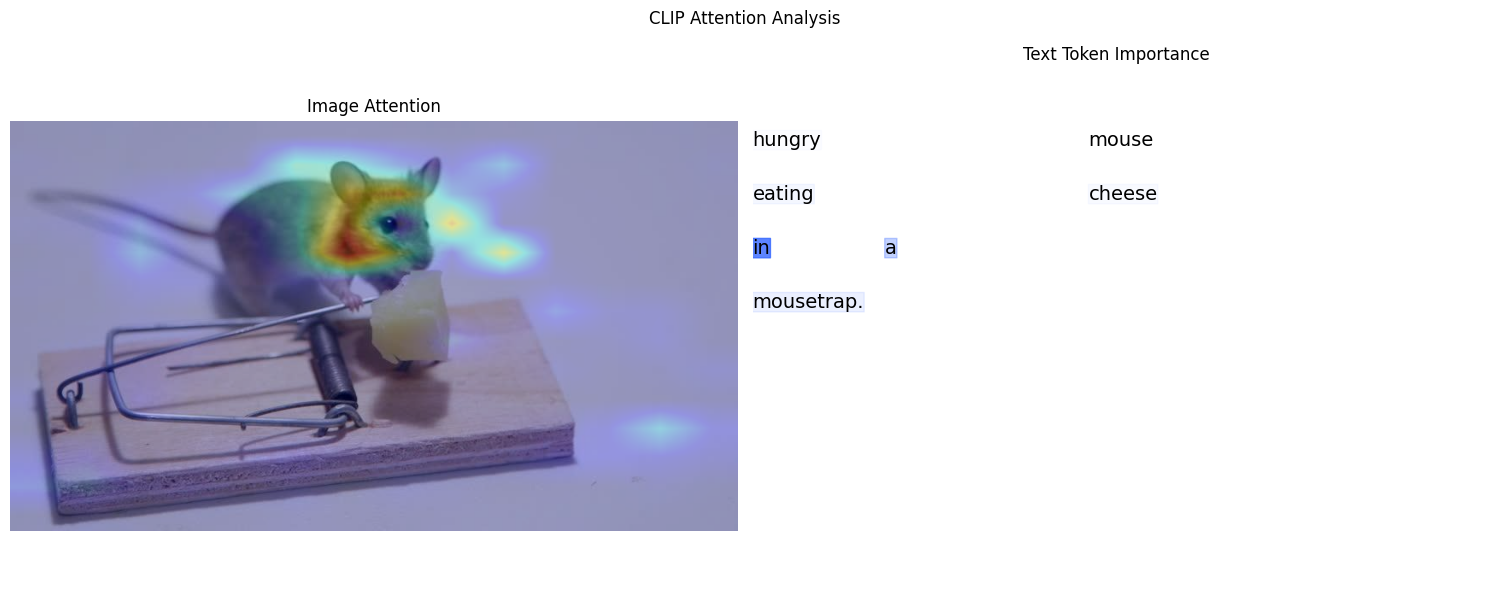

In [129]:
# Initialize analyzer and get results
analyzer = CLIPGradientAnalyzer()
results = analyzer.analyze(
    image_path="/home/mi3dr/Desktop/M2IB/images/mouse.jpg",
    text="hungry mouse eating cheese in a mousetrap.",
    return_tensors=True
)

# Get the enhanced features
#image_enhanced = results['image_enhanced']
#text_enhanced = results['text_enhanced']
#print(f"get analyzer enhanced image: {image_enhanced.shape}")
#print(f"get analyzer enhanced text: {text_enhanced.shape}")

# Analyze features using IB
vision_map, text_map, losses, processed_image = analyze_features_with_ib(
    image_enhanced=image_enhanced,
    text_enhanced=text_enhanced,
    original_image=results['original_image'],
    tokens=results['tokens'],
    beta=0.1,
    steps=100
)